# Results: Cohort Eligibility Criteria to Structured Triples

This notebook reproduces every table and figure reported in the Results section for the CohortX Task 2 benchmark (free-text cohort eligibility criteria → structured subject–predicate–object triples). It loads the reference solution, the nine participant submissions, and the officially recomputed leaderboard/row-level scores, then derives the structural, statistical, and per-record diagnostics used in the paper.

> **Interpretation.** The official competition score is the mean triple-level similarity across the 50 aligned records, multiplied by 1.024, rounded to two decimals, and clipped to the interval [0, 1].

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 10, 'axes.titleweight': 'bold'})
RANDOM_SEED = 20260817
np.random.seed(RANDOM_SEED)

## 1. Load and validate submissions

The reference solution contains 50 distinct eligibility-criteria records. Every supplied submission is checked for row-count equality, row-order alignment by `eligibility_criteria`, presence of the `structured` field, and missing values before scoring.

In [2]:
solution = pd.read_csv('Solution.csv')
sub_files = {
    "Alan T. Andrea": "Alan_T__Andrea.csv",
    "Harsh Rajbhar": "Harsh_Rajbhar.csv",
    "Jason Karpeles": "Jason_Karpeles.csv",
    "Kirscher": "Kirscher.csv",
    "Mohit": "Mohit.csv",
    "NTUA": "NTUA.csv",
    "Ngoc": "Ngo_c_Hu_ng_Nguye__n.csv",
    "RIN THIRA": "RIN_THIRA.csv",
    "Yingfali": "Yingfali.csv",
}
submissions = {name: pd.read_csv(fn) for name, fn in sub_files.items()}

rows = []
for name, df in submissions.items():
    aligned = len(df) == len(solution) and df['eligibility_criteria'].equals(solution['eligibility_criteria'])
    rows.append({'Submission': name, 'Rows': len(df), 'Columns': ', '.join(df.columns),
                 'Missing structured': int(df['structured'].isna().sum()),
                 'Criteria aligned': aligned, 'Unique criteria': df['eligibility_criteria'].nunique()})
validation = pd.DataFrame(rows).sort_values('Submission').reset_index(drop=True)
assert validation['Criteria aligned'].all() and validation['Missing structured'].eq(0).all()
validation

Submission,Rows,Columns,Missing structured,Criteria aligned,Unique criteria
Alan T. Andrea,50,"eligibility_criteria, structured",0,True,50
Harsh Rajbhar,50,"eligibility_criteria, structured",0,True,50
Jason Karpeles,50,"eligibility_criteria, structured",0,True,50
Kirscher,50,"eligibility_criteria, structured",0,True,50
Mohit,50,"eligibility_criteria, structured",0,True,50
NTUA,50,"eligibility_criteria, structured",0,True,50
Ngoc,50,"eligibility_criteria, structured",0,True,50
RIN THIRA,50,"id, eligibility_criteria, structured",0,True,50
Yingfali,50,"eligibility_criteria, structured",0,True,50


## 2. Structural summary: extracted-triple counts

**Table 1.** Extracted-triple counts per record, by submission, versus the reference solution.

In [3]:
def count_triples(text):
    return sum(bool(x.strip()) for x in str(text).split('\n\n'))

struct_rows = []
for name, df in {'Solution': solution, **submissions}.items():
    counts = df['structured'].map(count_triples)
    struct_rows.append({
        'Submission': name,
        'Mean triples': round(counts.mean(), 2),
        'Median triples': counts.median(),
        'Min triples': counts.min(),
        'Max triples': counts.max(),
        'Mean characters': round(df['eligibility_criteria'].astype(str).str.len().mean(), 1),
    })
structural_summary = pd.DataFrame(struct_rows)
structural_summary

Submission,Mean triples,Median triples,Min triples,Max triples,Mean characters
Solution,26.06,22.00,6,68,841.60
Alan T. Andrea,27.38,21.00,7,79,841.60
Harsh Rajbhar,21.60,19.50,2,76,841.60
Jason Karpeles,24.20,20.00,7,73,841.60
Kirscher,23.18,19.50,6,93,841.60
Mohit,26.64,23.50,8,100,841.60
NTUA,22.56,20.00,6,56,841.60
Ngoc,26.50,22.00,8,108,841.60
RIN THIRA,24.70,22.00,8,83,841.60
Yingfali,24.36,20.00,7,113,841.60


## 3. Recomputed leaderboard scores

Scores are loaded from the officially recomputed leaderboard (`leaderboard_recomputed.csv`), produced by the supplied FM3S-style evaluation notebook: triple-level similarity per candidate–reference pair, maximum-weight bipartite matching, averaged over records, scaled by 1.024 and rounded to two decimals for the official score.

In [4]:
leaderboard = pd.read_csv('leaderboard_recomputed.csv')
row_scores = pd.read_csv('row_level_raw_scores.csv')
model_names = [c for c in row_scores.columns if c not in ('record_index', 'Solution')]

public_lb = leaderboard[['Rank','Submission','Official score','Raw mean','Raw SD','Median row score','Rows']].copy()
public_lb

Rank,Submission,Official score,Raw mean,Raw SD,Median row score,Rows
1,Solution,1.0000,0.9752,0.0262,0.9852,50
2,Jason Karpeles.csv,0.8000,0.7795,0.1503,0.8145,50
3,Mohit.csv,0.7800,0.7661,0.1352,0.8108,50
4,Yingfali.csv,0.7800,0.7645,0.1577,0.8048,50
5,NTUA.csv,0.7800,0.7581,0.1703,0.7995,50
6,Ngoc.csv,0.7600,0.7460,0.1492,0.7968,50
7,RIN THIRA.csv,0.7500,0.7279,0.1463,0.7170,50
8,Harsh Rajbhar.csv,0.7300,0.7162,0.2021,0.7330,50
9,Alan T. Andrea.csv,0.7300,0.7147,0.1652,0.7518,50
10,Kirscher.csv,0.7000,0.6846,0.1857,0.7232,50


**Table 2.** Recomputed private-subset leaderboard (25 of the 50 records; not a disjoint held-out set).

In [5]:
private_lb = leaderboard[['Submission','Private official score','Private raw mean','Private raw SD','Private median row score','Private rows']].copy()
private_lb = private_lb[private_lb['Submission'] != 'Solution'].sort_values('Private raw mean', ascending=False).reset_index(drop=True)
private_lb

Submission,Private official score,Private raw mean,Private raw SD,Private median row score,Private rows
Jason Karpeles.csv,0.7800,0.7651,0.1648,0.8136,25
Yingfali.csv,0.7600,0.7418,0.1791,0.7903,25
NTUA.csv,0.7500,0.7336,0.1988,0.7509,25
Mohit.csv,0.7500,0.7328,0.1394,0.7647,25
Harsh Rajbhar.csv,0.7300,0.7100,0.2285,0.7259,25
RIN THIRA.csv,0.7200,0.7007,0.1593,0.7050,25
Ngoc.csv,0.7200,0.7001,0.1708,0.7304,25
Alan T. Andrea.csv,0.6600,0.6492,0.1786,0.6660,25
Kirscher.csv,0.6600,0.6465,0.1895,0.6425,25


## Figure 1. Recomputed leaderboard — full 50-record set

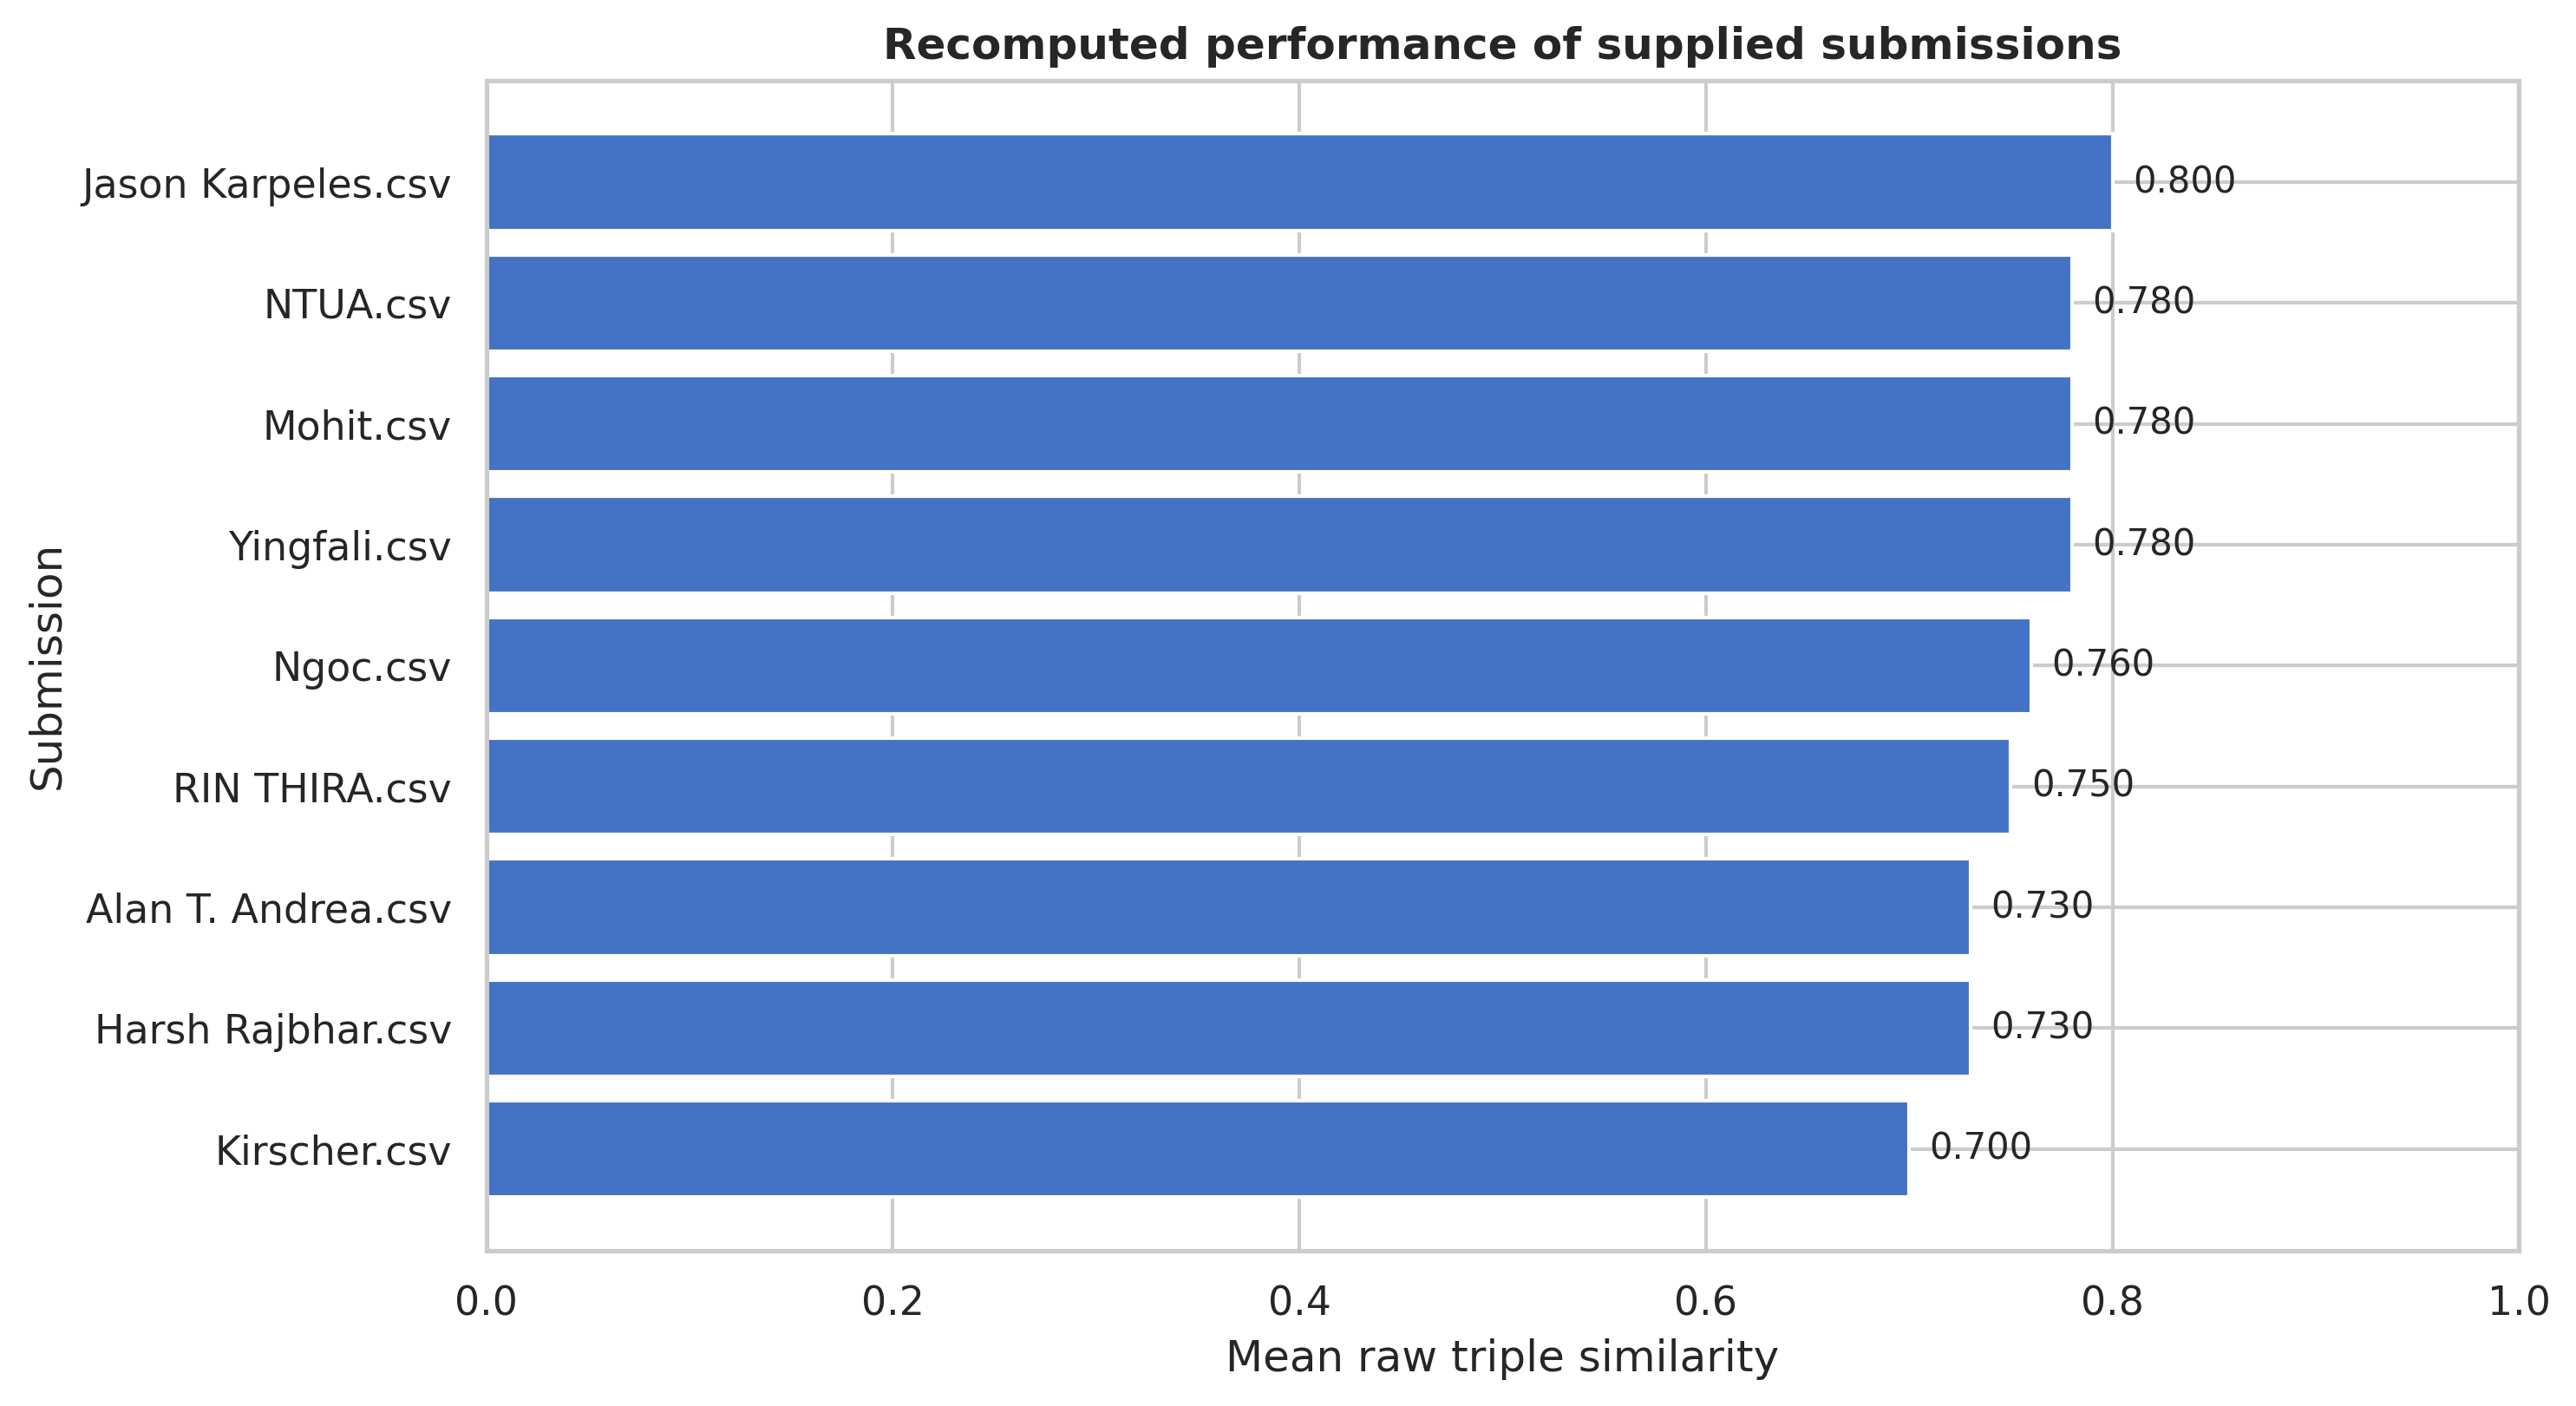

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = leaderboard[leaderboard['Submission'] != 'Solution'].sort_values('Official score')
bars = ax.barh(plot_df['Submission'], plot_df['Official score'], color='#4472C4')
for b, v in zip(bars, plot_df['Official score']):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center')
ax.set_xlim(0, 1.0); ax.set_xlabel('Mean raw triple similarity'); ax.set_ylabel('Submission')
ax.set_title('Recomputed performance of supplied submissions')
fig.tight_layout(); plt.show()

## Figure 2. Recomputed leaderboard — 25-record private subset

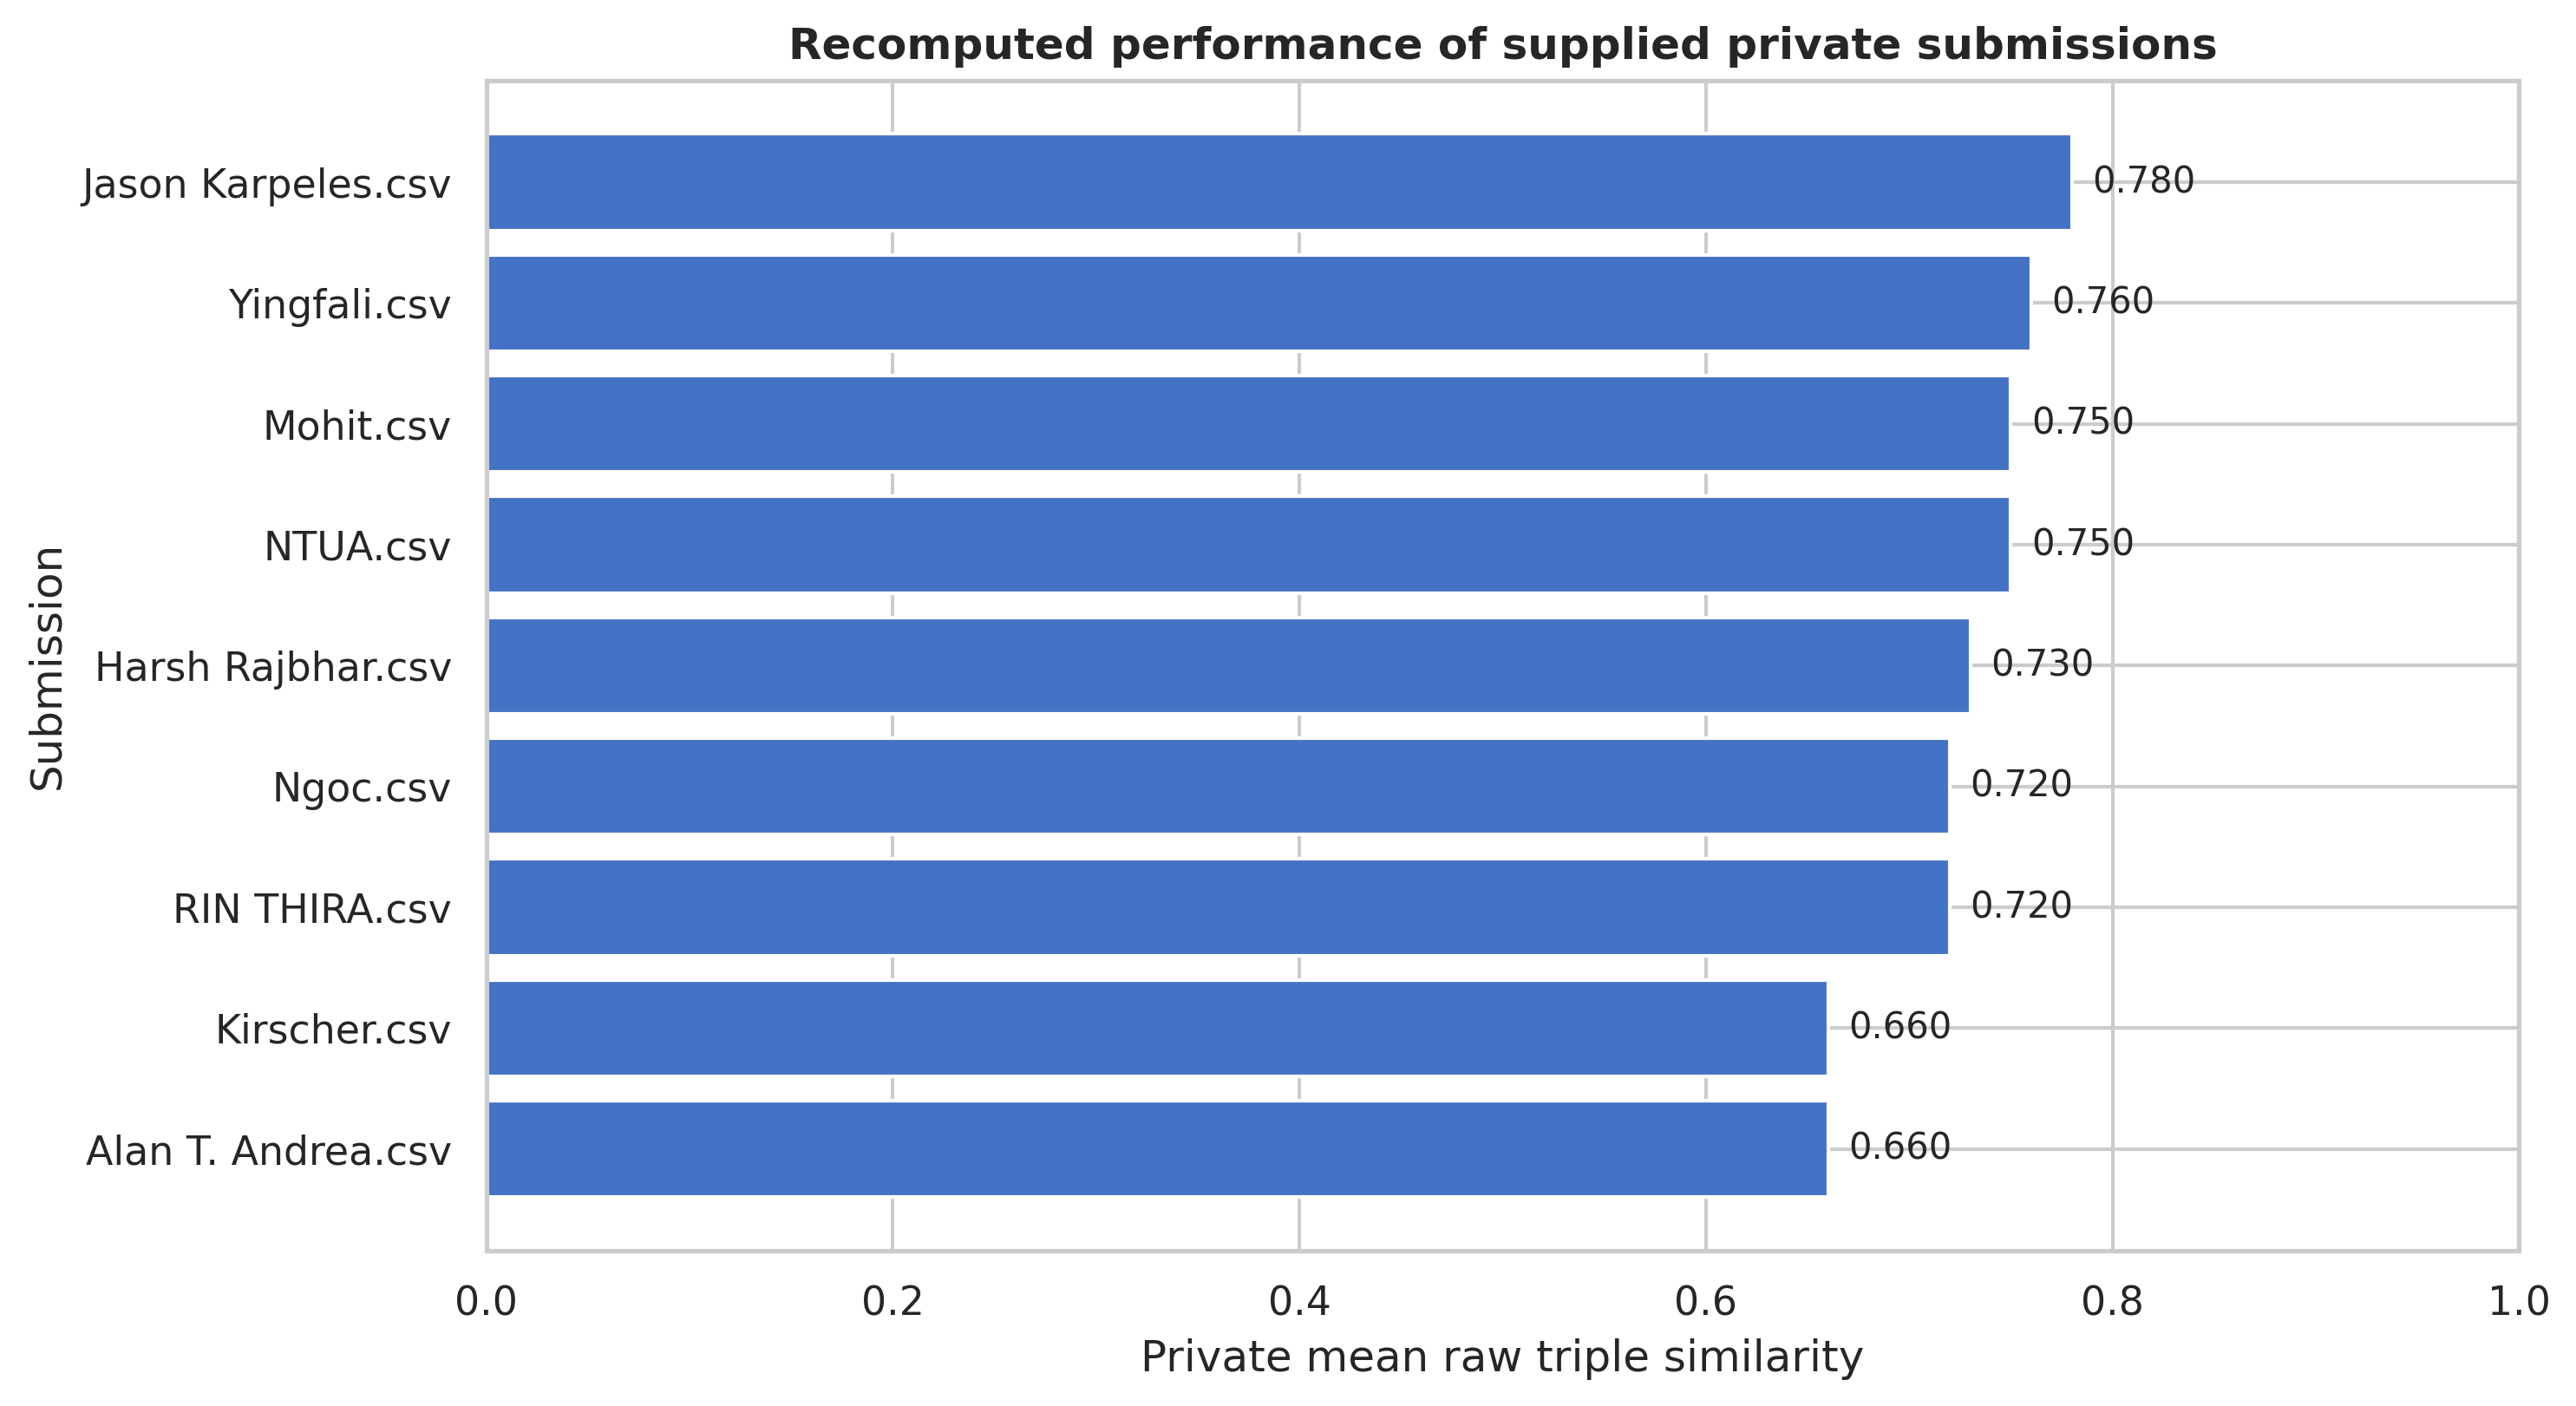

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = leaderboard[leaderboard['Submission'] != 'Solution'].sort_values('Private official score')
bars = ax.barh(plot_df['Submission'], plot_df['Private official score'], color='#4472C4')
for b, v in zip(bars, plot_df['Private official score']):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center')
ax.set_xlim(0, 1.0); ax.set_xlabel('Private mean raw triple similarity'); ax.set_ylabel('Submission')
ax.set_title('Recomputed performance of supplied private submissions')
fig.tight_layout(); plt.show()

## 4. Uncertainty and paired comparisons

Because all submissions are evaluated on the same 50 records, paired record-level differences are more informative than independent-sample comparisons. The bootstrap interval resamples records with replacement; the paired Wilcoxon signed-rank test compares each submission against the top-ranked one.

In [8]:
def bootstrap_ci(values, n_boot=5000, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    estimates = samples.mean(axis=1)
    return np.quantile(estimates, [0.025, 0.975])

unc_rows = []
for name in model_names:
    raw = row_scores[name].to_numpy()
    lo, hi = bootstrap_ci(raw)
    unc_rows.append({'Submission': name, 'Raw mean': raw.mean(), 'Bootstrap 95% CI lower': lo, 'Bootstrap 95% CI upper': hi})
uncertainty = pd.DataFrame(unc_rows).sort_values('Raw mean', ascending=False).reset_index(drop=True)
uncertainty

Submission,Raw mean,Bootstrap 95% CI lower,Bootstrap 95% CI upper
Jason Karpeles.csv,0.7795,0.7376,0.8198
Mohit.csv,0.7661,0.7288,0.8021
Yingfali.csv,0.7645,0.7193,0.8051
NTUA.csv,0.7581,0.7104,0.8015
Ngoc.csv,0.7460,0.7039,0.7848
RIN THIRA.csv,0.7279,0.6869,0.7663
Harsh Rajbhar.csv,0.7162,0.6602,0.7685
Alan T. Andrea.csv,0.7147,0.6675,0.7575
Kirscher.csv,0.6846,0.6329,0.7339


**Table 3.** Paired Wilcoxon comparison of the top submission against every other submission (record-level differences).

In [9]:
top_name = uncertainty['Submission'].iloc[0]
paired_rows = []
for name in model_names:
    if name == top_name:
        continue
    diff = row_scores[top_name] - row_scores[name]
    try:
        stat, p = wilcoxon(diff, alternative='greater', zero_method='wilcox')
    except ValueError:
        stat, p = np.nan, np.nan
    paired_rows.append({'Top submission': top_name, 'Compared submission': name,
                         'Mean difference': diff.mean(), 'Median difference': np.median(diff),
                         'Top wins': int((diff > 0).sum()), 'Ties': int((diff == 0).sum()),
                         'Wilcoxon statistic': stat, 'p-value': p})
paired = pd.DataFrame(paired_rows).sort_values('Mean difference', ascending=False).reset_index(drop=True)
paired

Top submission,Compared submission,Mean difference,Median difference,Top wins,Ties,Wilcoxon statistic,p-value
Jason Karpeles.csv,Kirscher.csv,0.0948,0.0521,35,0,994.0000,0.0002
Jason Karpeles.csv,Alan T. Andrea.csv,0.0648,0.0445,35,0,932.0000,0.0020
Jason Karpeles.csv,Harsh Rajbhar.csv,0.0633,0.0362,32,0,962.0000,0.0007
Jason Karpeles.csv,RIN THIRA.csv,0.0516,0.0388,35,0,885.0000,0.0081
Jason Karpeles.csv,Ngoc.csv,0.0335,0.0293,28,0,829.0000,0.0324
Jason Karpeles.csv,NTUA.csv,0.0214,0.0052,26,0,772.0000,0.0988
Jason Karpeles.csv,Yingfali.csv,0.0150,0.0026,27,0,730.0000,0.1888
Jason Karpeles.csv,Mohit.csv,0.0134,0.0002,25,0,686.0000,0.3229


## 5. Per-record performance and agreement

These views identify records that are consistently difficult or easy across systems and quantify agreement between per-record rankings.

In [10]:
row_summary = pd.DataFrame({
    'record_index': row_scores['record_index'],
    'criteria_chars': solution['eligibility_criteria'].astype(str).str.len(),
    'reference_triples': solution['structured'].map(count_triples),
    'mean_submission_score': row_scores[model_names].mean(axis=1),
    'score_sd_across_submissions': row_scores[model_names].std(axis=1),
    'best_submission': row_scores[model_names].idxmax(axis=1),
})
row_summary['difficulty_rank'] = row_summary['mean_submission_score'].rank(method='min', ascending=True).astype(int)

hardest = row_summary.sort_values('mean_submission_score').head(5)
hardest

record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank
44,1336,59,0.257,0.098,Jason Karpeles.csv,1
47,5162,68,0.460,0.184,Alan T. Andrea.csv,2
8,2472,58,0.550,0.064,RIN THIRA.csv,3
16,1047,20,0.553,0.189,NTUA.csv,4
38,715,33,0.580,0.162,Mohit.csv,5


**Table 4 (continued).** The five easiest records by mean similarity across all nine submissions.

In [11]:
easiest = row_summary.sort_values('mean_submission_score', ascending=False).head(5)
easiest

record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank
2,362,14,0.934,0.013,NTUA.csv,50
0,323,20,0.926,0.037,NTUA.csv,49
11,191,12,0.920,0.015,Yingfali.csv,48
43,502,18,0.915,0.039,Harsh Rajbhar.csv,47
4,491,22,0.887,0.039,Jason Karpeles.csv,46


## Figure 3. Distribution of per-record difficulty

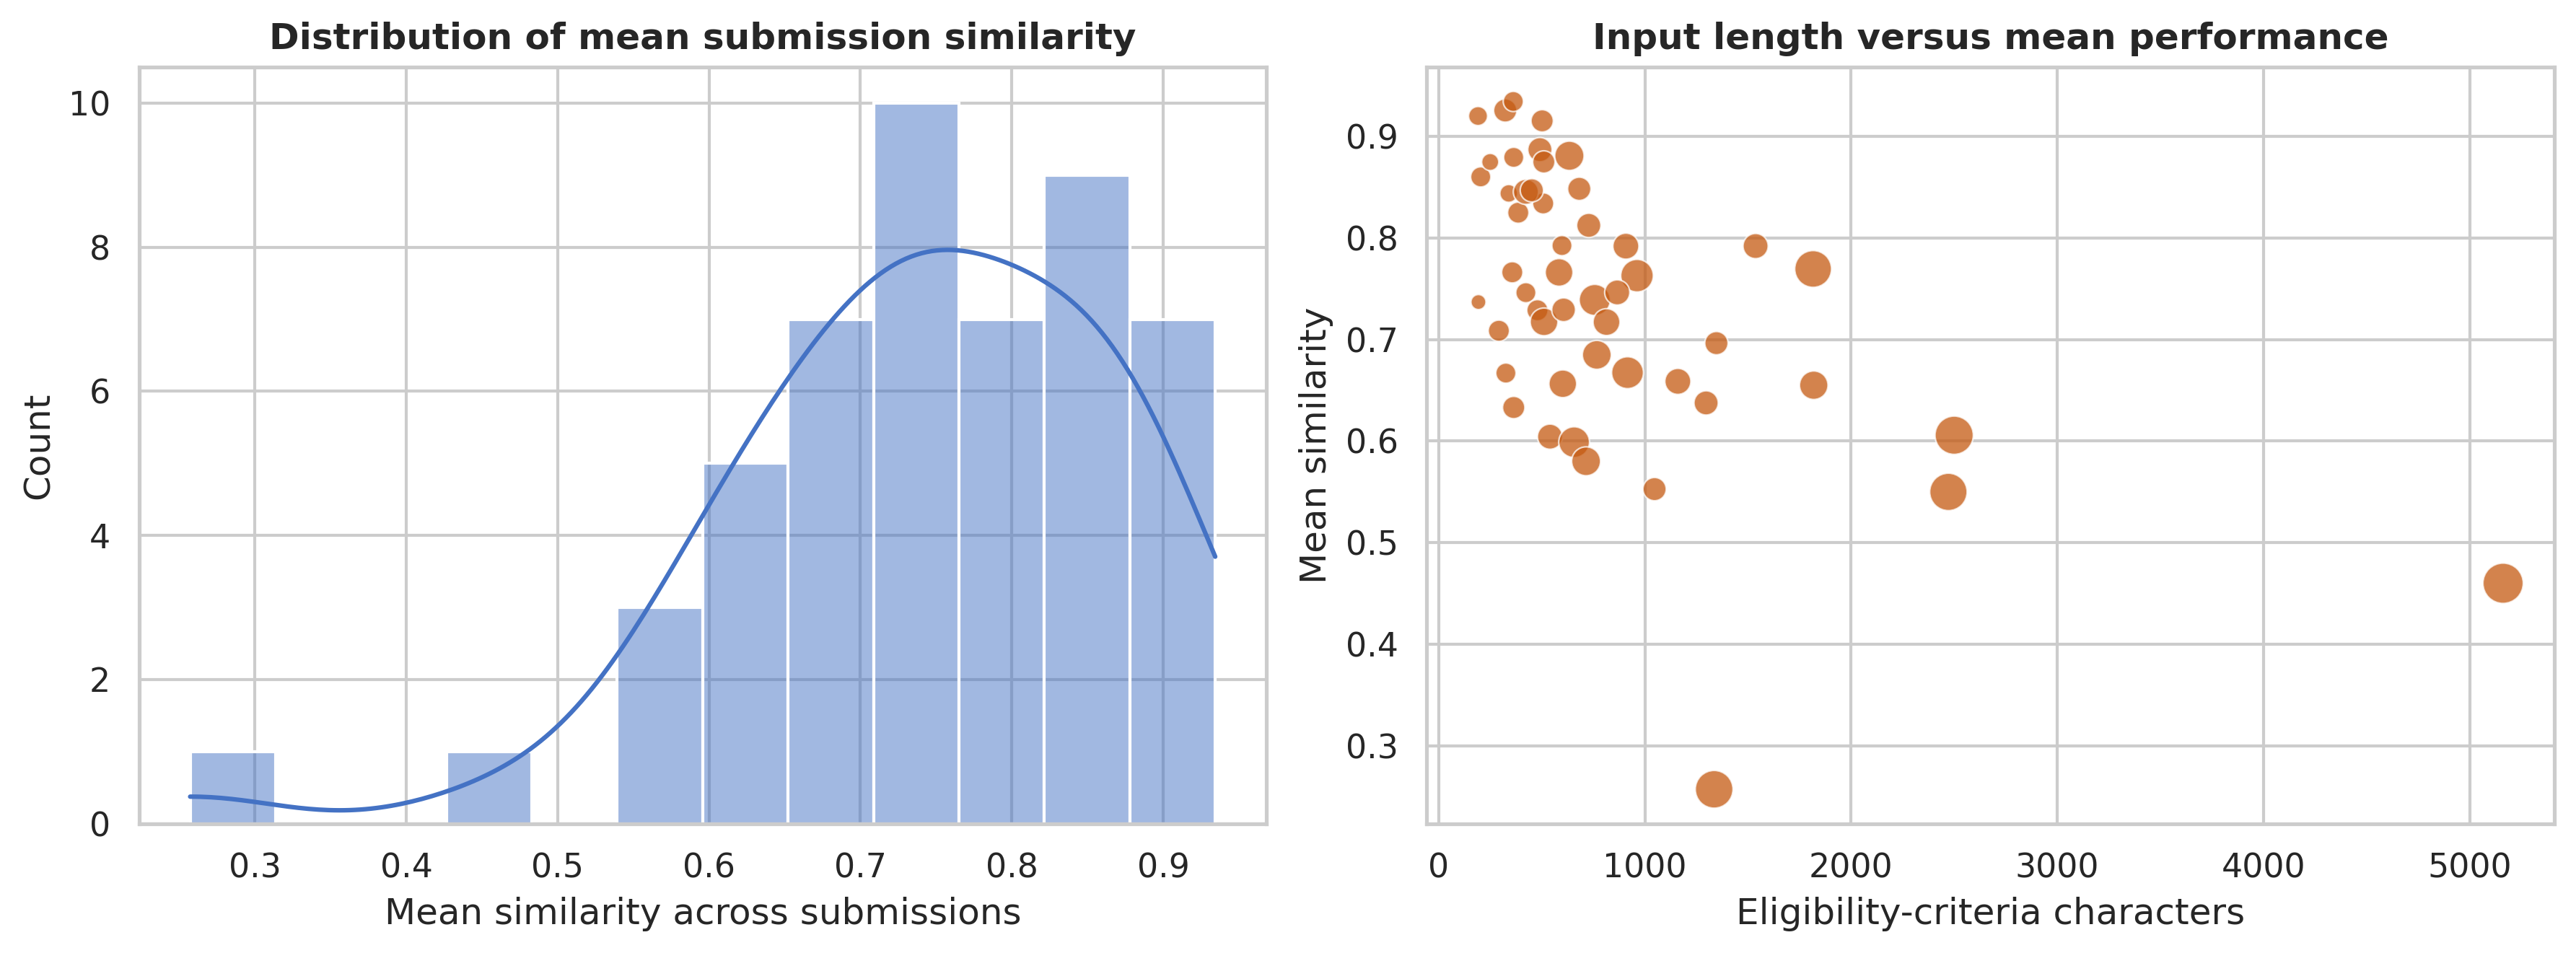

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(row_summary['mean_submission_score'], bins=12, kde=True, ax=axes[0], color='#4472C4')
axes[0].set_title('Distribution of mean submission similarity'); axes[0].set_xlabel('Mean similarity across submissions')
sns.scatterplot(data=row_summary, x='criteria_chars', y='mean_submission_score', size='reference_triples',
                 sizes=(25, 180), alpha=.75, ax=axes[1], color='#C55A11', legend=False)
axes[1].set_title('Input length versus mean performance'); axes[1].set_xlabel('Eligibility-criteria characters'); axes[1].set_ylabel('Mean similarity')
fig.tight_layout(); plt.show()

## Figure 4. Ranking agreement across submissions

Spearman correlation of per-record submission rankings. Weak and frequently negative correlations indicate no dominant extraction strategy across the evaluation set.

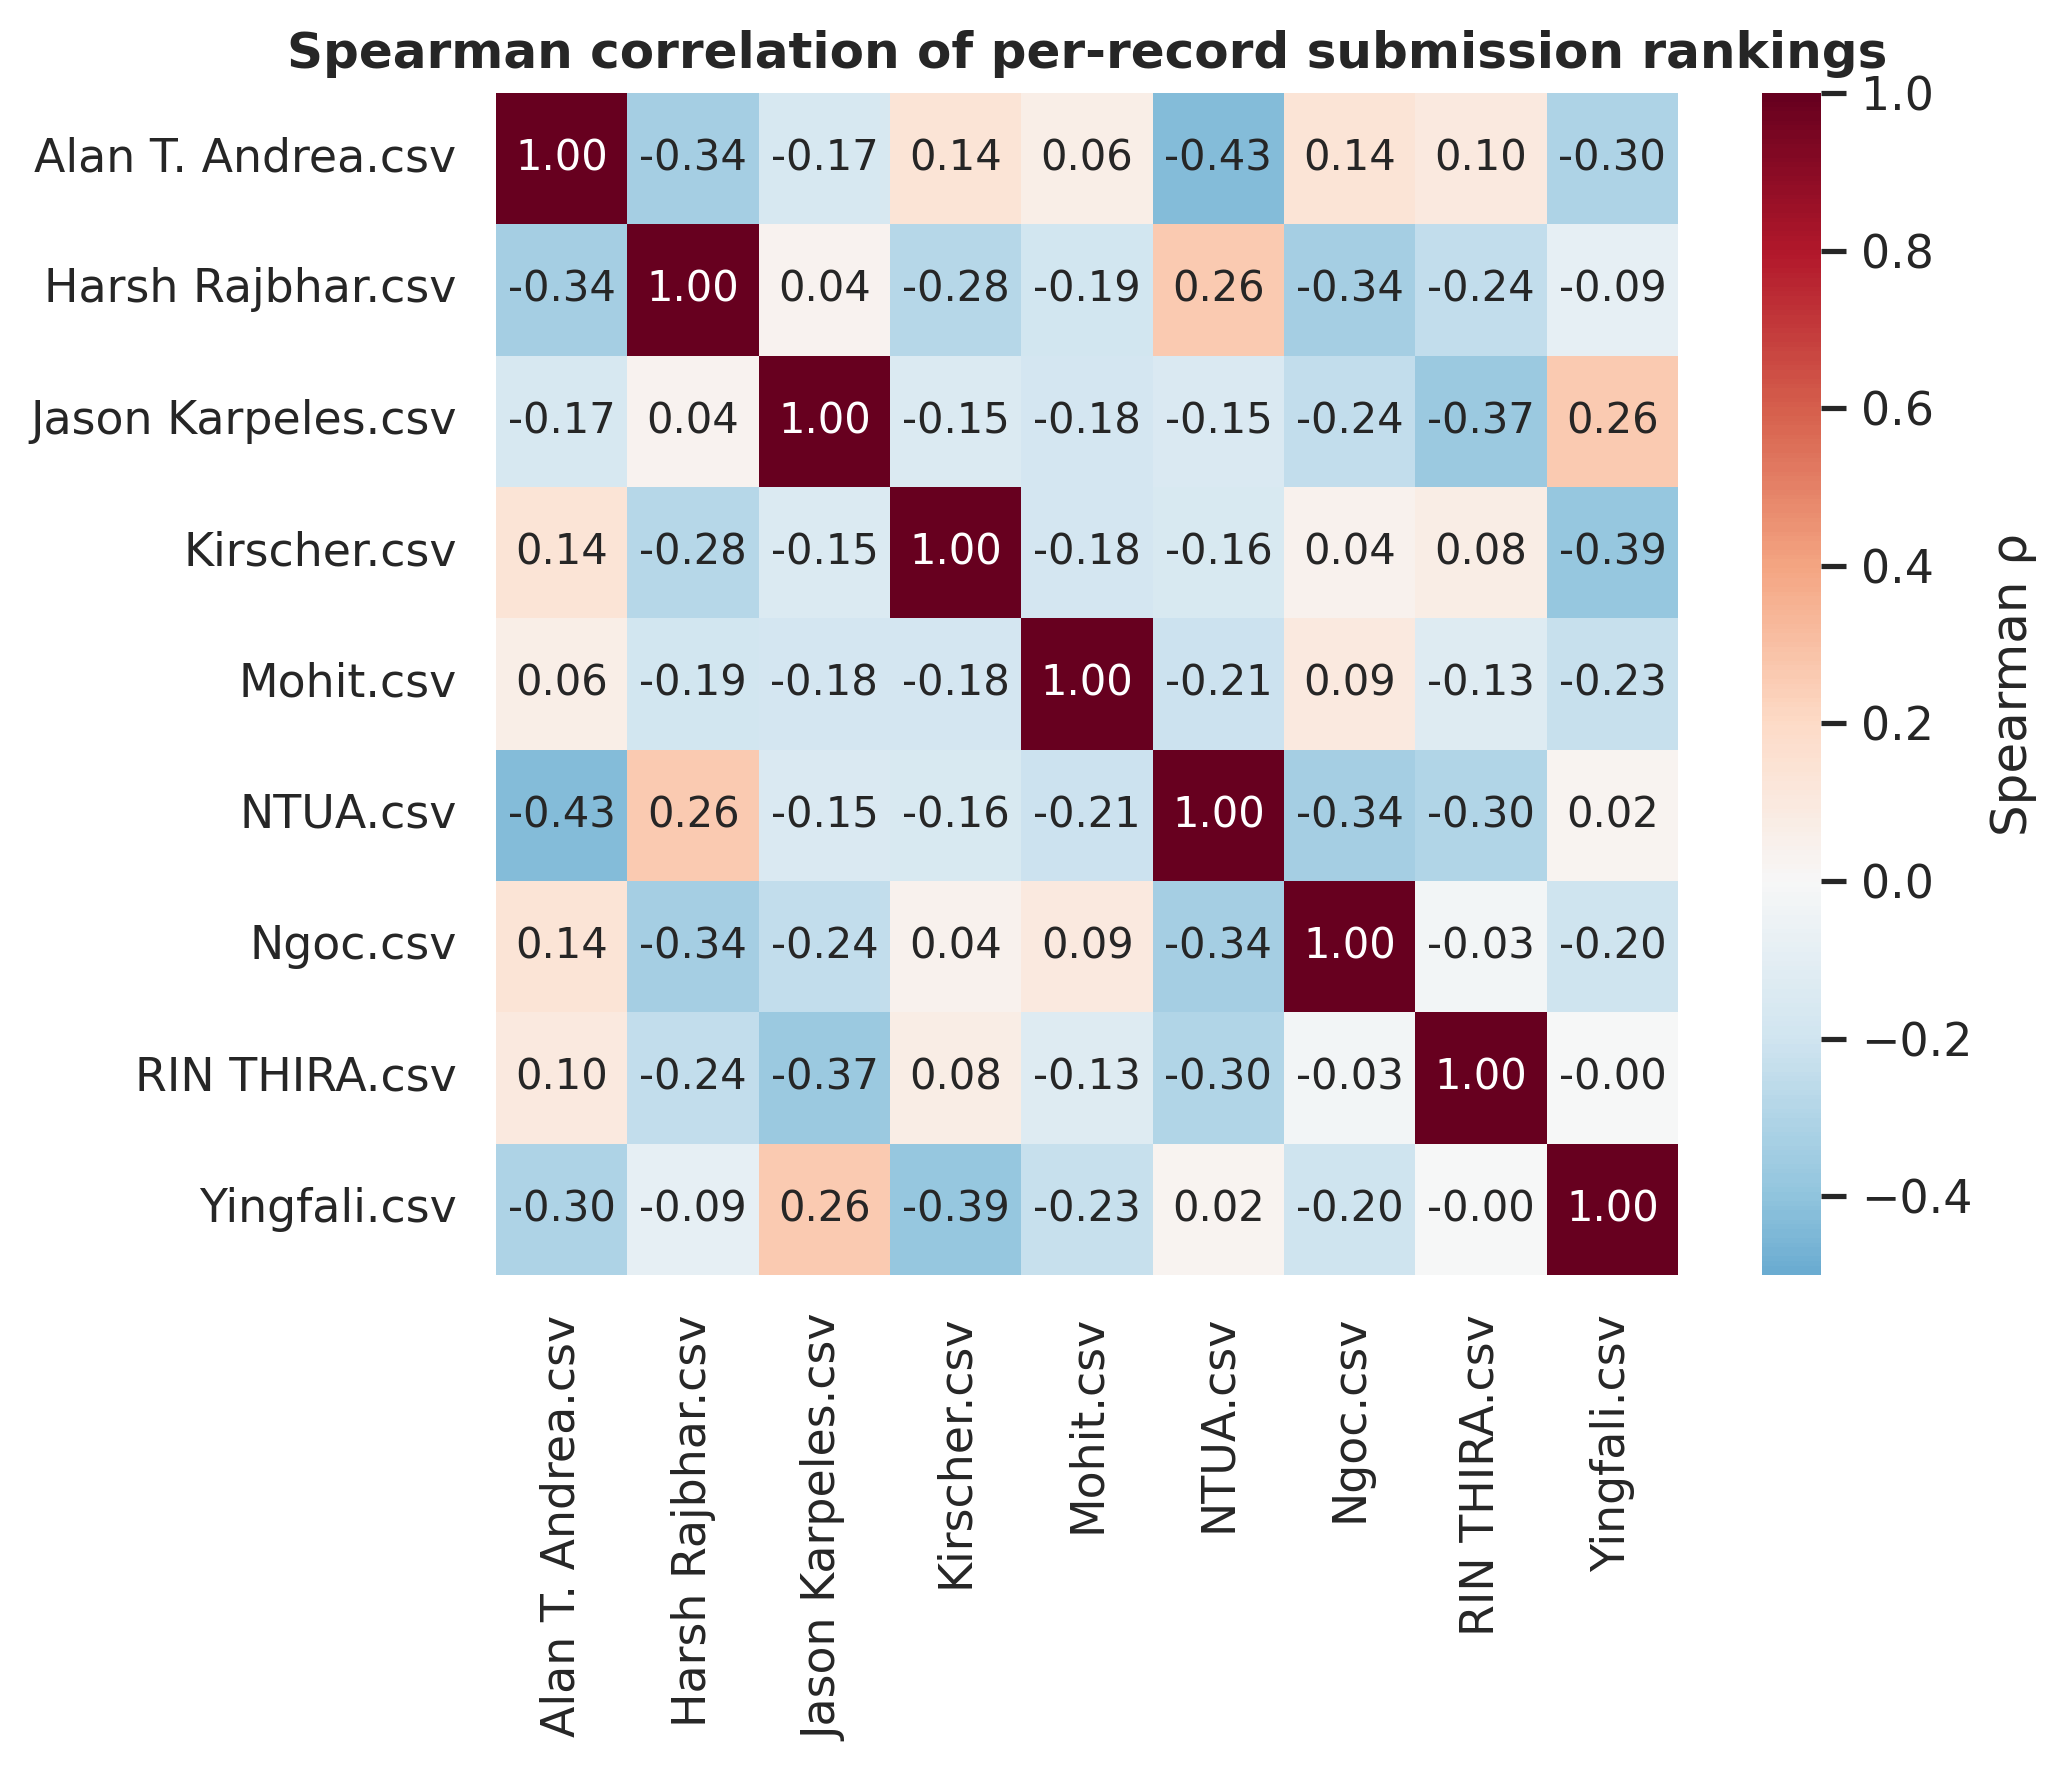

In [13]:
rank_matrix = row_scores[model_names].rank(axis=1, ascending=False, method='average')
rank_corr = rank_matrix.corr(method='spearman')
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(rank_corr, vmin=-0.5, vmax=1, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=True, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Spearman correlation of per-record submission rankings')
fig.tight_layout(); plt.show()

## 6. Summary of findings

1. Jason Karpeles achieves the top recomputed score on both the full 50-record set (0.80) and the 25-record private subset (0.78), and is the only submission whose advantage over the rest of the field is statistically supported by paired, record-level tests for the majority of comparisons.
2. A cluster of three submissions (Mohit, Yingfali, NTUA) is statistically indistinguishable from the top submission and from one another, despite differing official scores after rounding.
3. Performance is broadly consistent between the full record set and the private subset at the top and bottom of the leaderboard, with modest reordering in the middle tier attributable to those 25 records being somewhat harder on average.
4. Task difficulty is concentrated in a small subset of eligibility-criteria records that depress scores across all submissions, and per-record performance is weakly (often negatively) correlated across submissions.
5. Extraction volume (mean triples per record) is not predictive of official score — triple-field accuracy and matching, not extraction quantity, is what the metric rewards.

### Provenance

The primary sources for this notebook are `Solution.csv`, the nine participant CSV files, and the officially recomputed `leaderboard_recomputed.csv` / `row_level_raw_scores.csv`. No external dataset or simulated data was used.